In [1]:
import pandas as pd

df = pd.read_csv("housing.csv")
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [2]:
df.shape

(20640, 10)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


In [4]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [5]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,207
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [6]:
df["total_bedrooms"] = df["total_bedrooms"].fillna(df["total_bedrooms"].median())

In [7]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0
ocean_proximity,0


In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df = df.drop_duplicates() # Duplicate removal

In [10]:
df_copy = df.copy()

In [11]:
df_copy.drop(columns="ocean_proximity", axis = 1)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0
...,...,...,...,...,...,...,...,...,...
20635,-121.09,39.48,25.0,1665.0,374.0,845.0,330.0,1.5603,78100.0
20636,-121.21,39.49,18.0,697.0,150.0,356.0,114.0,2.5568,77100.0
20637,-121.22,39.43,17.0,2254.0,485.0,1007.0,433.0,1.7000,92300.0
20638,-121.32,39.43,18.0,1860.0,409.0,741.0,349.0,1.8672,84700.0


In [12]:
corr = df.corr(numeric_only= True)

<Axes: >

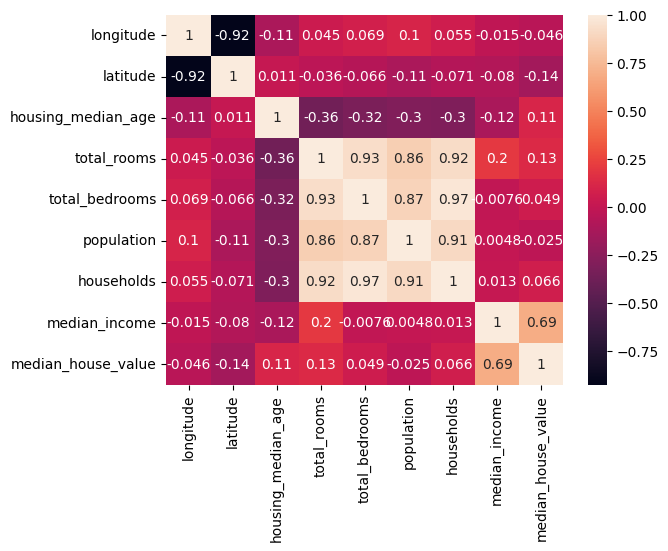

In [13]:
import seaborn as sns
sns.heatmap(corr, annot= True, )

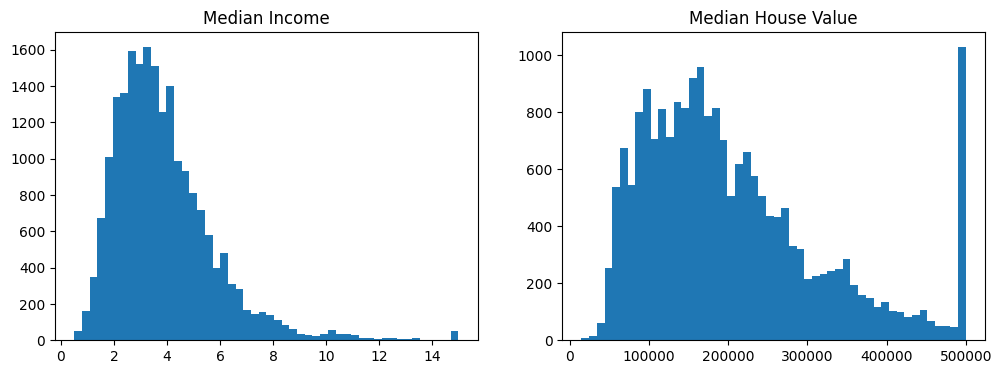

In [14]:
import matplotlib.pyplot as plt

fig , axes = plt.subplots(1,2, figsize= (12,4))
axes[0].hist(df["median_income"], bins = 50)
axes[0].set_title("Median Income")
axes[1].set_title("Median House Value")
axes[1].hist(df["median_house_value"], bins = 50)
plt.show()

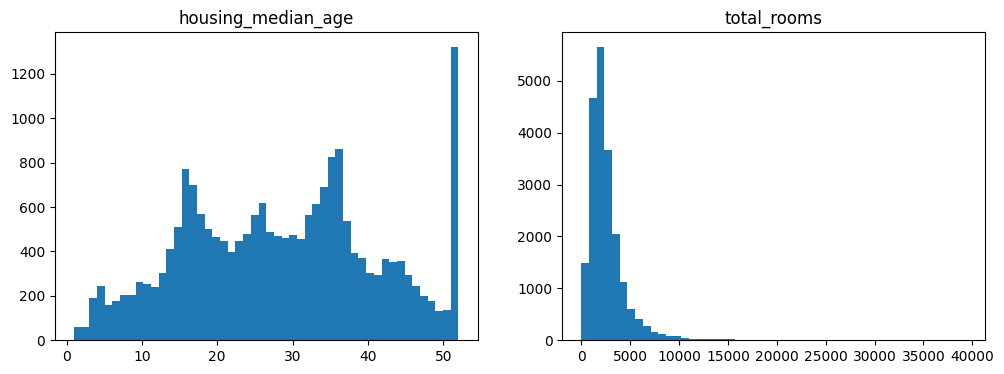

In [15]:
fig , axes = plt.subplots(1,2, figsize= (12,4))
axes[0].hist(df["housing_median_age"], bins = 50)
axes[0].set_title("housing_median_age")
axes[1].set_title("total_rooms")
axes[1].hist(df["total_rooms"], bins = 50)
plt.show()

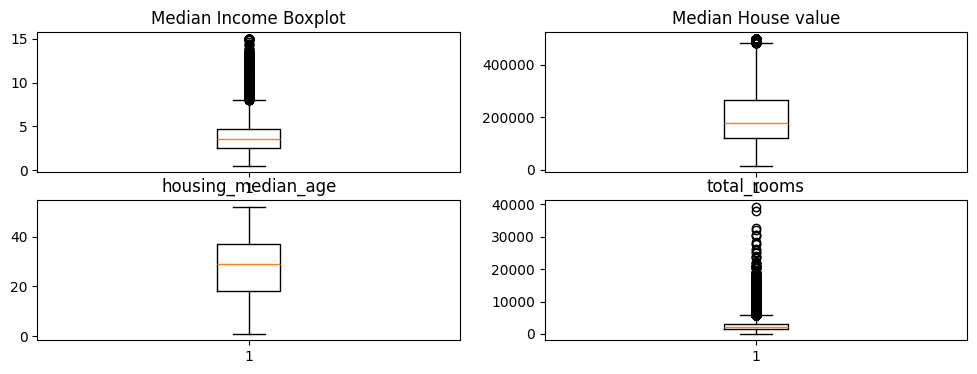

In [16]:
fig , axes = plt.subplots(2,2, figsize= (12,4))
axes[0,0].boxplot(df["median_income"])
axes[0, 0].set_title("Median Income Boxplot")

axes[0,1].boxplot(df["median_house_value"])
axes[0,1].set_title("Median House value")

axes[1,0].boxplot(df["housing_median_age"])
axes[1, 0].set_title("housing_median_age")

axes[1, 1].boxplot(df["total_rooms"])
axes[1,1].set_title("total_rooms")

plt.show()

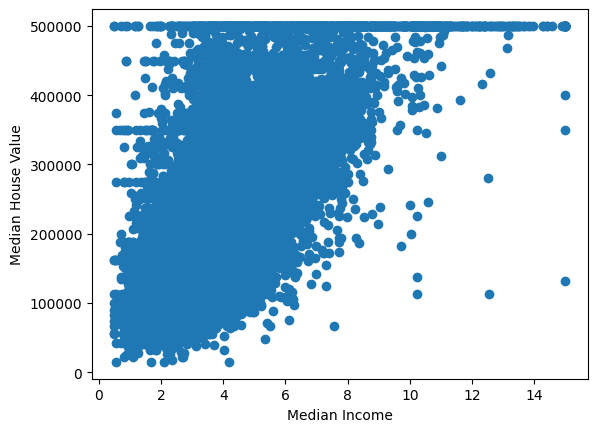

In [17]:
plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

In [18]:
capped_rows = (df["median_house_value"] == 500001).sum()
print(capped_rows)

965


In [19]:
df = df[df["median_house_value"] != 500001]

In [20]:
df.shape

(19675, 10)

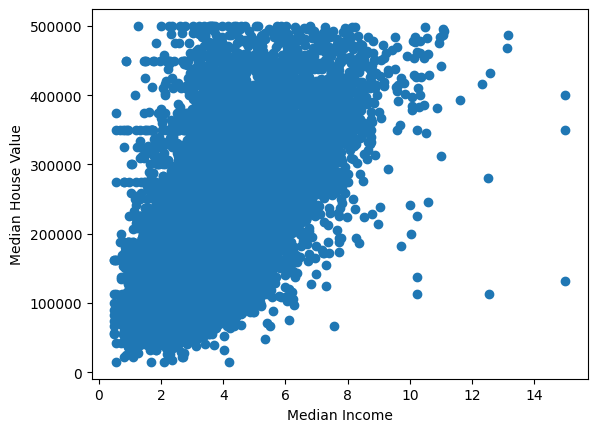

In [21]:
plt.scatter(df["median_income"], df["median_house_value"])
plt.xlabel("Median Income")
plt.ylabel("Median House Value")
plt.show()

In [22]:
Q1 = df["median_income"].quantile(0.25)
Q3 = df["median_income"].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df["median_income"] = df["median_income"].clip(lower_bound, upper_bound)

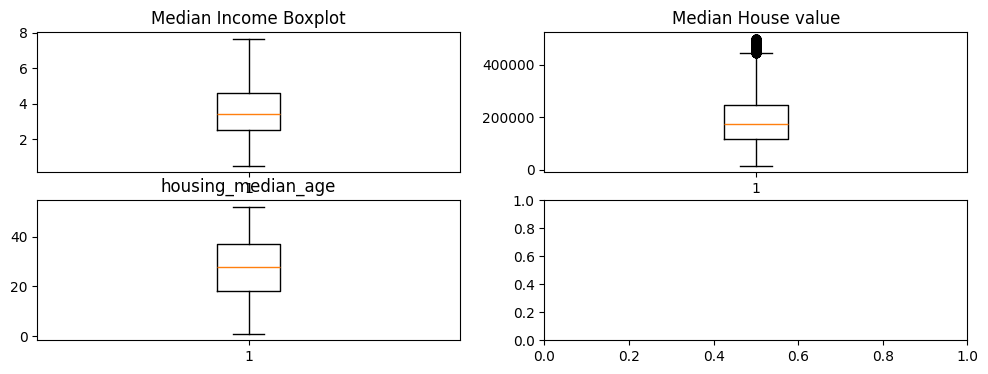

In [23]:
fig , axes = plt.subplots(2,2, figsize= (12,4))
axes[0,0].boxplot(df["median_income"])
axes[0, 0].set_title("Median Income Boxplot")

axes[0,1].boxplot(df["median_house_value"])
axes[0,1].set_title("Median House value")

axes[1,0].boxplot(df["housing_median_age"])
axes[1, 0].set_title("housing_median_age")

plt.show()

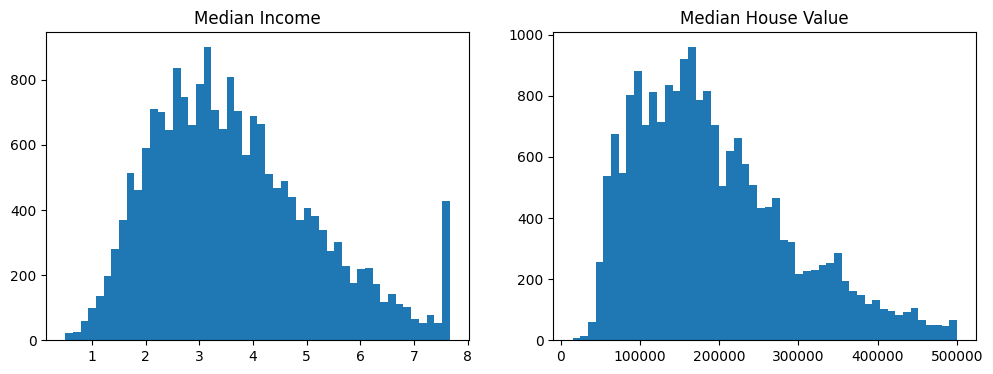

In [24]:
import matplotlib.pyplot as plt

fig , axes = plt.subplots(1,2, figsize= (12,4))
axes[0].hist(df["median_income"], bins = 50)
axes[0].set_title("Median Income")
axes[1].set_title("Median House Value")
axes[1].hist(df["median_house_value"], bins = 50)
plt.show()

In [26]:
# Feature Selection
X = df[["median_income", "housing_median_age", "total_rooms"]] # X --> Features
y = df["median_house_value"] # Y --> Target

In [28]:
# Train/ Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size= 0.2)

In [29]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((15740, 3), (3935, 3), (15740,), (3935,))

In [30]:
# Train Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [31]:
model.fit(X_train, y_train) # Train a model

LinearRegression()

In [32]:
model.coef_

array([4.38002364e+04, 1.75531971e+03, 3.19743381e+00])

In [33]:
model.intercept_

np.float64(-26184.2512479063)

In [34]:
y_pred = model.predict(X_test) # predicting from the model

In [35]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error: ", mae)
print("Mean Squared Error: ", mse)
print("Root Mean Squared Error: ", rmse)
print("R2 Score: ", r2)

Mean Absolute Error:  54198.62475166892
Mean Squared Error:  5184833270.6788
Root Mean Squared Error:  72005.78636942172
R2 Score:  0.4431949663791771


# IT explains only 41 % variance of the data

In [36]:
n = len(y_test)
p = X_test.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print("Adjusted R2 Score: ", adjusted_r2)

Adjusted R2 Score:  0.44277003249445
